#  **Тесты/демонстрация** реализации стохастических методов оптимизации поверх конструктивного числа

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [40]:
from google.colab import files

uploaded = files.upload()

Saving ConstructiveNumber.py to ConstructiveNumber (6).py
Saving functions.py to functions (6).py
Saving random_search.py to random_search (6).py
Saving simulated_annealing.py to simulated_annealing (6).py


In [41]:
from ConstructiveNumber import ConstructiveNumber

from functions import (
    SphereFunction,
    RosenbrockFunction,
    RastriginFunction,
    AckleyFunction,
    HimmelblauFunction,
    DesmosDiscontinuousFunction,
)

from random_search import RandomSearch
from simulated_annealing import SimulatedAnnealing

## Список тестовых функций

In [42]:
functions = [
    {
        "objective": SphereFunction(n=2),
        "bounds": [(-5, 5), (-5, 5)],
    },
    {
        "objective": RosenbrockFunction(n=2),
        "bounds": [(-3, 3), (-3, 3)],
    },
    {
        "objective": RastriginFunction(n=2),
        "bounds": [(-5.12, 5.12), (-5.12, 5.12)],
    },
    {
        "objective": AckleyFunction(),
        "bounds": [(-5, 5), (-5, 5)],
    },
    {
        "objective": HimmelblauFunction(),
        "bounds": [(-5, 5), (-5, 5)],
    },
    {
        "objective": DesmosDiscontinuousFunction(),
        "bounds": [(-5, 5), (-5, 5)],
    },
]

## Список методов

In [43]:
methods = [

    RandomSearch(
        max_iter=3000,
        eps=1e-6,
        seed=42
    ),

    SimulatedAnnealing(
        max_iter=3000,
        initial_temperature=10.0,
        cooling_rate=0.995,
        step_size=0.5,
        eps=1e-6,
        seed=42
    ),
]

## Запуск тестов

In [46]:
results = []

for item in functions:

    objective = item["objective"]
    bounds = item["bounds"]

    for method in methods:

        objective.reset_counters()

        result = method.optimize(objective, bounds)

        results.append({
            "function": objective.name(),
            "method": result["method"],
            "f_best": result["f_best"].to_float() if hasattr(result["f_best"], "to_float") else float(result["f_best"]),
            "iterations": result["iterations"],
            "func_calls": result["stats"]["func_calls"],
            "time_sec": result["time_sec"],
            "memory_peak_bytes": result["memory_peak_bytes"],
        })

print("Тесты завершены.")

Тесты завершены.


## Таблица результатов

In [47]:
df = pd.DataFrame(results)
df

,function,method,f_best,iterations,func_calls,time_sec,memory_peak_bytes
0,Sphere function (2 variables),RandomSearch,0.005487,3000,3001,3.012814,928008
1,Sphere function (2 variables),SimulatedAnnealing,0.000016,3000,3001,2.714536,834268
2,Rosenbrock function (2 variables),RandomSearch,0.056507,3000,3001,2.677803,709204
3,Rosenbrock function (2 variables),SimulatedAnnealing,0.002509,3000,3001,3.212653,817260
4,Rastrigin function (2 variables),RandomSearch,1.063857,3000,3001,4.889391,709732
5,Rastrigin function (2 variables),SimulatedAnnealing,3.996717,3000,3001,4.229959,811256
6,Ackley function,RandomSearch,0.350470,3000,3001,1.645030,710404
7,Ackley function,SimulatedAnnealing,0.025704,3000,3001,2.254923,812500
8,Himmelblau function,RandomSearch,0.004561,3000,3001,4.041348,704628
9,Himmelblau function,SimulatedAnnealing,0.001452,3000,3001,3.357275,815876


In [48]:
df.to_csv("results.csv", index=False)

## Построение графиков

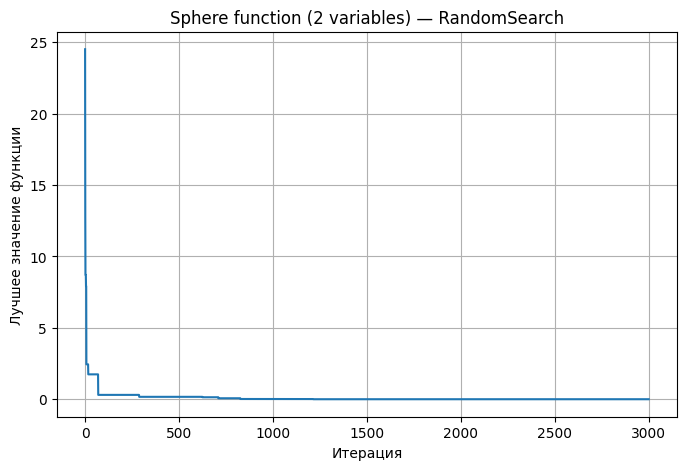

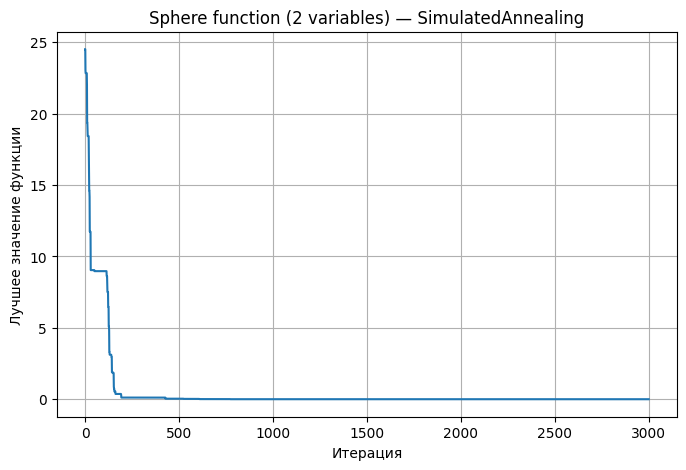

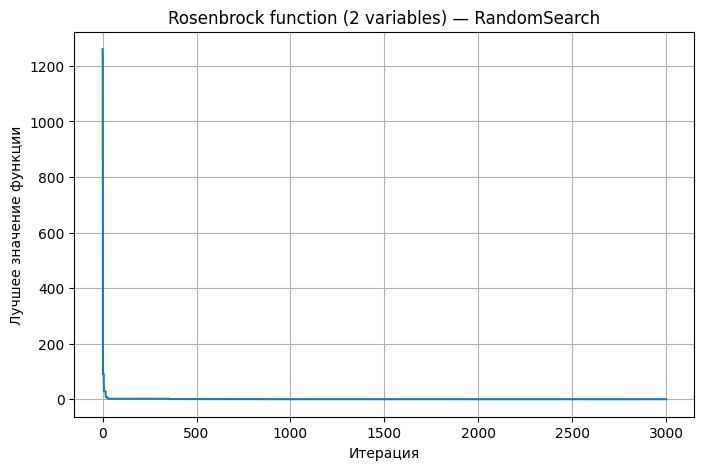

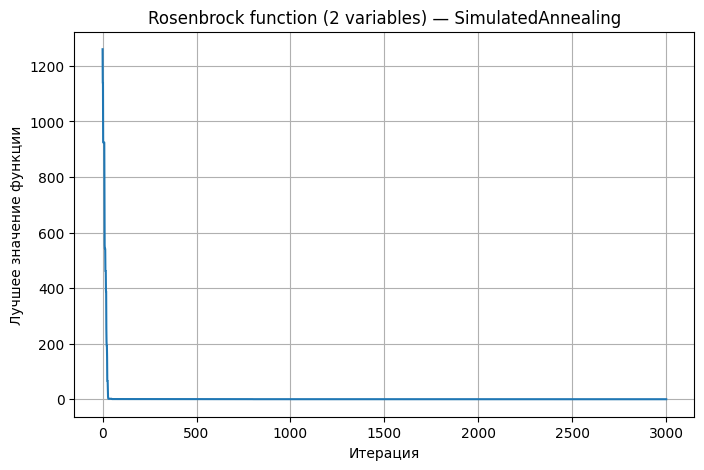

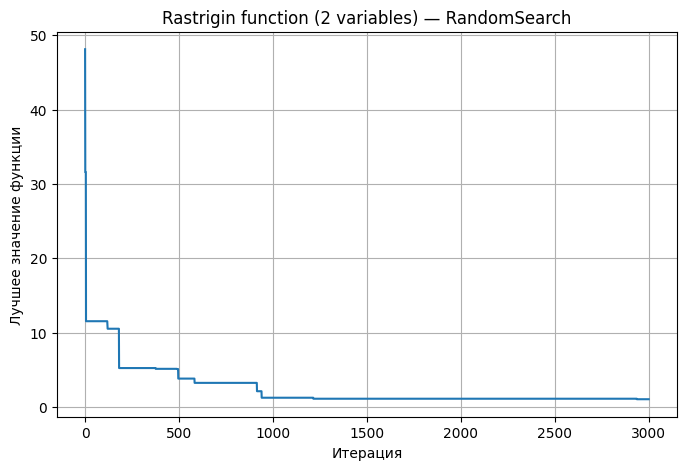

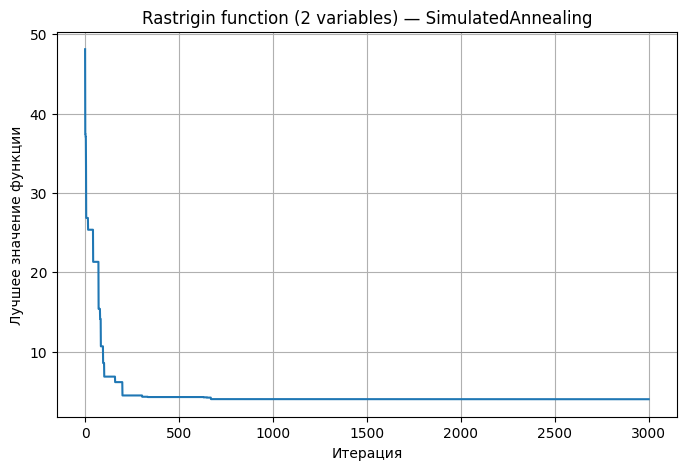

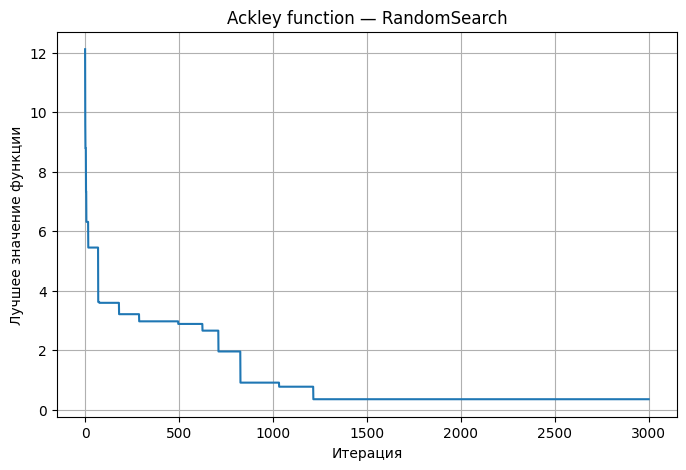

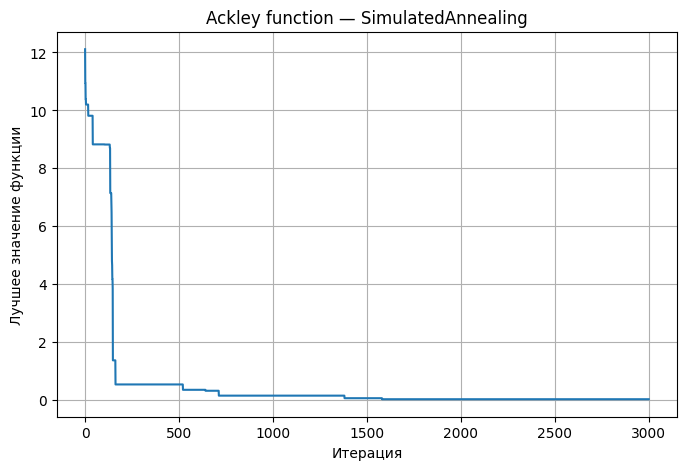

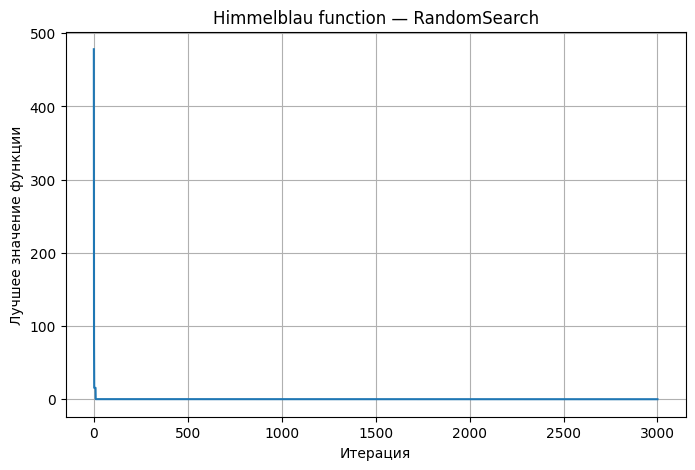

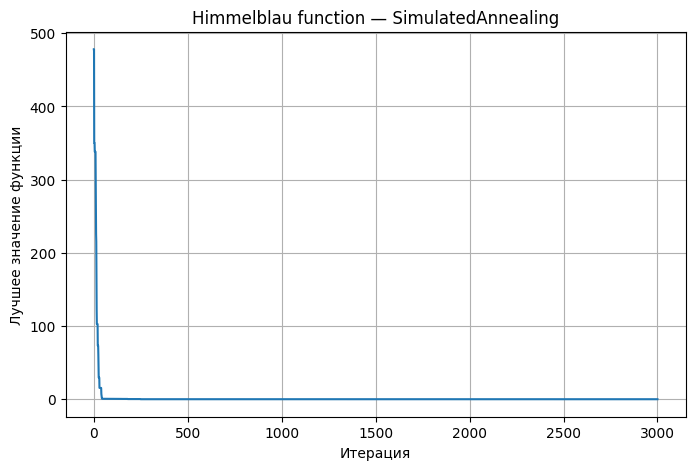

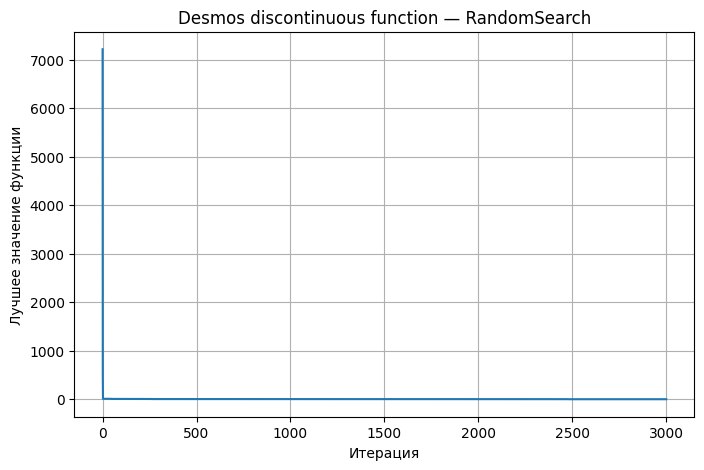

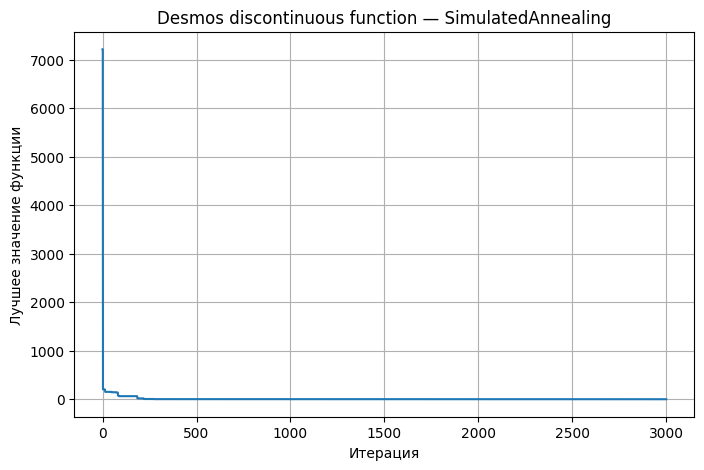

In [49]:
for item in functions:

    objective = item["objective"]
    bounds = item["bounds"]

    for method in methods:

        objective.reset_counters()

        result = method.optimize(objective, bounds)

        plt.figure(figsize=(8, 5))
        plt.plot(result["func_values"])
        plt.xlabel("Итерация")
        plt.ylabel("Лучшее значение функции")
        plt.title(f'{objective.name()} — {result["method"]}')
        plt.grid(True)
        plt.show()